In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords
import nltk
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
import joblib

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/test/spam_assassin.csv")
df

,text,target
0,From ilug-admin@linux.ie Mon Jul 29 11:28:02 2...,0
1,From gort44@excite.com Mon Jun 24 17:54:21 200...,1
2,From fork-admin@xent.com Mon Jul 29 11:39:57 2...,1
3,From dcm123@btamail.net.cn Mon Jun 24 17:49:23...,1
4,From ilug-admin@linux.ie Mon Aug 19 11:02:47 2...,0
...,...,...
5791,From ilug-admin@linux.ie Mon Jul 22 18:12:45 2...,0
5792,From fork-admin@xent.com Mon Oct 7 20:37:02 20...,0
5793,Received: from hq.pro-ns.net (localhost [127.0...,1
5794,From razor-users-admin@lists.sourceforge.net T...,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5796 entries, 0 to 5795
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    5796 non-null   object
 1   target  5796 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 90.7+ KB


In [ ]:
df.head()

,text,target
0,From ilug-admin@linux.ie Mon Jul 29 11:28:02 2...,0
1,From gort44@excite.com Mon Jun 24 17:54:21 200...,1
2,From fork-admin@xent.com Mon Jul 29 11:39:57 2...,1
3,From dcm123@btamail.net.cn Mon Jun 24 17:49:23...,1
4,From ilug-admin@linux.ie Mon Aug 19 11:02:47 2...,0


In [ ]:
df['target'].value_counts()

,count
target,
0,3900
1,1896


In [ ]:
df=df.drop_duplicates()

In [ ]:
df=df.dropna(subset=['text'])

In [ ]:
df.shape

(5329, 2)

In [ ]:
df['text_length'] = df['text'].apply(len)

In [ ]:
df['text_length'].describe()

,text_length
count,5329.000000
mean,4164.186527
std,6030.253952
min,362.000000
25%,2390.000000
50%,3296.000000
75%,4492.000000
max,232305.000000


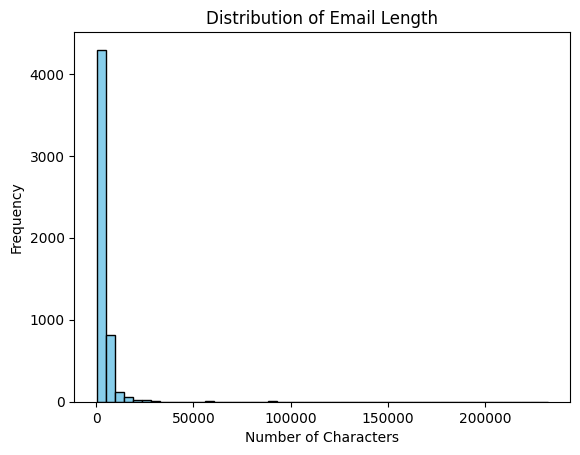

In [ ]:
plt.hist(df['text_length'], bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of Email Length')
plt.xlabel('Number of Characters')
plt.ylabel('Frequency')
plt.show()

In [ ]:
df[df['target'] == 1]['text'].iloc[0:2]

,text
1,From gort44@excite.com Mon Jun 24 17:54:21 200...
2,From fork-admin@xent.com Mon Jul 29 11:39:57 2...


In [ ]:
df[df['target'] == 0]['text'].iloc[0:2]

,text
0,From ilug-admin@linux.ie Mon Jul 29 11:28:02 2...
4,From ilug-admin@linux.ie Mon Aug 19 11:02:47 2...


In [ ]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
df

,text,target,text_length
0,From ilug-admin@linux.ie Mon Jul 29 11:28:02 2...,0,4098
1,From gort44@excite.com Mon Jun 24 17:54:21 200...,1,2189
2,From fork-admin@xent.com Mon Jul 29 11:39:57 2...,1,3598
3,From dcm123@btamail.net.cn Mon Jun 24 17:49:23...,1,1918
4,From ilug-admin@linux.ie Mon Aug 19 11:02:47 2...,0,3060
...,...,...,...
5791,From ilug-admin@linux.ie Mon Jul 22 18:12:45 2...,0,3732
5792,From fork-admin@xent.com Mon Oct 7 20:37:02 20...,0,3334
5793,Received: from hq.pro-ns.net (localhost [127.0...,1,5050
5794,From razor-users-admin@lists.sourceforge.net T...,0,8068


In [ ]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = ' '.join([word for word in text.split() if word not in stop_words])
    return text

In [ ]:
df['clean_text'] = df['text'].apply(clean_text)

In [ ]:
df[['text', 'clean_text']].head()

,text,clean_text
0,From ilug-admin@linux.ie Mon Jul 29 11:28:02 2...,ilugadminlinuxie mon jul returnpath ilugadminl...
1,From gort44@excite.com Mon Jun 24 17:54:21 200...,gortexcitecom mon jun returnpath gortexcitecom...
2,From fork-admin@xent.com Mon Jul 29 11:39:57 2...,forkadminxentcom mon jul returnpath forkadminx...
3,From dcm123@btamail.net.cn Mon Jun 24 17:49:23...,dcmbtamailnetcn mon jun returnpath dcmbtamailn...
4,From ilug-admin@linux.ie Mon Aug 19 11:02:47 2...,ilugadminlinuxie mon aug returnpath ilugadminl...


In [ ]:
df = df[['clean_text', 'target']]
df

,clean_text,target
0,ilugadminlinuxie mon jul returnpath ilugadminl...,0
1,gortexcitecom mon jun returnpath gortexcitecom...,1
2,forkadminxentcom mon jul returnpath forkadminx...,1
3,dcmbtamailnetcn mon jun returnpath dcmbtamailn...,1
4,ilugadminlinuxie mon aug returnpath ilugadminl...,0
...,...,...
5791,ilugadminlinuxie mon jul returnpath ilugadminl...,0
5792,forkadminxentcom mon oct returnpath forkadminx...,0
5793,received hqpronsnet localhost hqpronsnet esmtp...,1
5794,razorusersadminlistssourceforgenet thu sep ret...,0


In [ ]:
vectorizer = TfidfVectorizer(max_features=5000)
x = vectorizer.fit_transform(df['clean_text']).toarray()

In [ ]:
x.shape

(5329, 5000)

In [ ]:
y= df['target'].values

In [ ]:
np.save("x_features.npy", x)
np.save("y_labels.npy", y)

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print(f"{len(x_train)}")
print(f"{len(x_test)}")


4263
1066


In [ ]:
model =LogisticRegression(max_iter=1000)


In [ ]:
model.fit(x_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred= model.predict(x_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9887


In [ ]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.99      1.00      0.99       726
           1       1.00      0.97      0.98       340

    accuracy                           0.99      1066
   macro avg       0.99      0.98      0.99      1066
weighted avg       0.99      0.99      0.99      1066



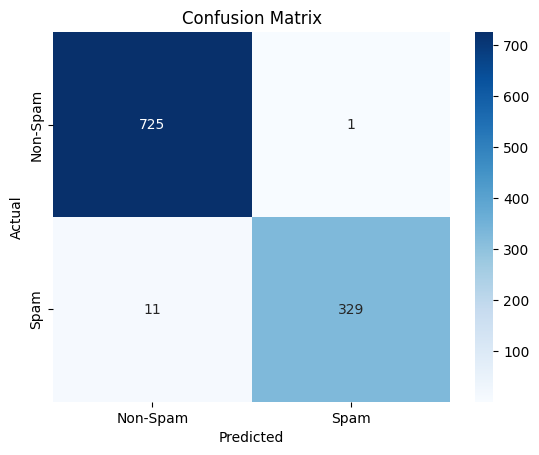

In [ ]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-Spam', 'Spam'], yticklabels=['Non-Spam', 'Spam'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
joblib.dump(model, 'spam_detection_model')

['spam_detection_model']